In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END

In [2]:
class AgentState(TypedDict):
    num1: int 
    op : str
    num2:int 
    finalNumber: int

In [3]:
def adder(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber"] = state["num1"] + state["num2"]

    return state

def subtractor(state:AgentState) -> AgentState:
    state["finalNumber"] = state["num1"] - state["num2"]

    return state

def decide_next_node(state:AgentState) -> AgentState:

   if state["op"] == "+":
    return "add_op"

   elif state["op"] == "-":
    return "sub_op"





In [4]:
g = StateGraph(AgentState)

g.add_node("add_node" , adder)
g.add_node("sub_node" , subtractor)
g.add_node("router" , lambda state : state) # Pass through it don't return anything 

g.add_edge(START , "router")

g.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "add_op":"add_node",
        "sub_op":"sub_node"
    }

)

g.add_edge("add_node" , END)
g.add_edge("sub_node" , END)

app = g.compile()

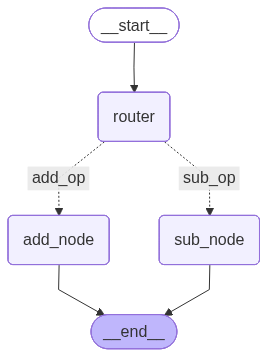

In [5]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
intial_state = AgentState(num1 = 10 , op = "-" , num2 = 20)
print(app.invoke(intial_state))

{'num1': 10, 'op': '-', 'num2': 20, 'finalNumber': -10}
